In [ ]:
import numpy as np
import torch
import copy
import random
from mdl_utils import make_graphs, tied_featurize, parse_PDB, create_labels
from mdl_utils import StructureDatasetPDB, EncoderProteinMPNN, DecoderProteinMPNN
import pandas as pd
from Bio.PDB import PDBParser, DSSP
import pandas as pd

In [ ]:
seed = 0
path_to_node_model_weights = "../training/exp_020/model_weights/node_log19_exp8"
model_name = 'epoch_last'
batch_size = 1
sampling_temp = "0.1"
pdb_path = "../evaluation/inputs/1cew.pdb"#"../analysis/pdb_files/scfv_native.pdb"
max_length = 200000
backbone_noise = 0.00
show_graphs = False
SAE_level = "node"

In [ ]:
def run_dssp(pdb_path):
    main_dict = {}
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("prot", str(pdb_path))
    model = structure[0]
    dssp = DSSP(model, str(pdb_path), dssp='~/miniconda3/envs/dssp_test/bin/mkdssp')
    
    for key in dssp.keys():
        try:
            idx = dssp[key][0] - 1
            aa, ss, asa, phi, psi = (
                dssp[key][1], dssp[key][2], dssp[key][3],
                dssp[key][4], dssp[key][5]
            )
            main_dict[idx] = round(asa, 3)
        except (TypeError, KeyError):
            continue
    df = pd.DataFrame(main_dict, index=['ASA']).T
    print(df)
    buried = df.index[df['ASA'] < 0.2].to_list()
    return buried

buried = run_dssp(pdb_path)
print(len(buried))
print(buried)

       ASA
0    1.000
1    0.575
2    0.441
3    0.577
4    0.691
..     ...
103  0.469
104  0.515
105  0.620
106  0.370
107  0.970

[108 rows x 1 columns]
30
[5, 11, 12, 15, 16, 19, 20, 24, 32, 33, 41, 44, 48, 51, 53, 55, 57, 58, 60, 62, 72, 73, 76, 86, 88, 89, 90, 91, 92, 93]


/home/neelm/miniconda3/envs/protmpnn/lib/python3.12/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


In [479]:
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)   

hidden_dim = 128
num_layers = 3 

model_folder_path = path_to_node_model_weights
if model_folder_path[-1] != '/':
    model_folder_path = model_folder_path + '/'

checkpoint_path = model_folder_path + f'{model_name}.pt'

BATCH_COPIES = batch_size
alphabet = 'ACDEFGHIKLMNPQRSTVWYX'   
device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")

pdb_dict_list = parse_PDB(pdb_path, ca_only=False)
dataset_valid = StructureDatasetPDB(pdb_dict_list, truncate=None, max_length=max_length)

basic_checkpoint_path = "../training/exp_020/v_48_020.pt"
checkpoint = torch.load(basic_checkpoint_path, map_location=device, weights_only=False)
node_checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Infer expansion size of latent space
size = int(node_checkpoint['model_state_dict']['sae_layers.0.WS1.weight'].shape[0] / 128)
encoder_model = EncoderProteinMPNN(num_letters=21,
                    node_features=hidden_dim,
                    edge_features=hidden_dim, 
                    hidden_dim=hidden_dim,
                    expansion=size,
                    num_encoder_layers=num_layers, 
                    num_decoder_layers=num_layers, 
                    augment_eps=backbone_noise, 
                    k_neighbors=checkpoint['num_edges'])
encoder_model.to(device)    

encoder_model.load_state_dict(checkpoint['model_state_dict'], strict=False)


filtered_node_state_dict = {}
for k, v in node_checkpoint['model_state_dict'].items():
    if 'sae_layers' in k:
      k = k[11:]
      filtered_node_state_dict[k] = v
encoder_model.node_sae_layers.load_state_dict(filtered_node_state_dict, strict=True)


encoder_model.eval()

decoder_model = DecoderProteinMPNN(num_letters=21,
                    node_features=hidden_dim,
                    edge_features=hidden_dim, 
                    hidden_dim=hidden_dim,
                    expansion=size,
                    num_encoder_layers=num_layers, 
                    num_decoder_layers=num_layers, 
                    augment_eps=backbone_noise, 
                    k_neighbors=48)
decoder_model.to(device)    
#basic_checkpoint_path = "../training/exp_020/v_48_020.pt"
basic_checkpoint = torch.load(basic_checkpoint_path, map_location=device, weights_only=False)
decoder_model.load_state_dict(basic_checkpoint['model_state_dict'], strict=False)

decoder_model.eval();

In [480]:
with torch.no_grad():
    for ix, protein in enumerate(dataset_valid):
        batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
        X, S, mask,_, chain_M, chain_encoding_all,_,_,_,_, chain_M_pos,_, residue_idx,_,_,_,_,_,_,_ = tied_featurize(batch_clones, device, chain_dict=None)
        if SAE_level == 'node':
            error, res_labels = create_labels(pdb_path, SAE_level)
            if error != True:
                randn_1 = torch.randn(chain_M.shape, device=device)
                h_V, h_E, n_original, n_encoded, n_decoded, E_idx, e_original, e_encoded, e_decoded = encoder_model(X, mask, residue_idx, chain_encoding_all)
            

In [481]:
if show_graphs:
    model_name = '/'.join(path_to_node_model_weights.split('/')[-1:])
    protein_name = pdb_path[-8:-4]
    layer = 2
    graph_info = [model_name, protein_name, layer, 'Node']
    make_graphs(n_original, "Original", 2, graph_info)
    make_graphs(n_encoded, "Encoded", 2, graph_info)
    make_graphs(n_decoded, "Decoded", 2, graph_info)

In [482]:
print(h_V.shape)
print(encoder_model.node_input_act[2].shape)

# log 17 node feature correlations:
bcaa = [46, 48, 182, 191, 221]

mask_for_empty = np.asarray((S[0] != 20).cpu())
print(encoder_model.node_encoded_act[2].cpu().numpy().shape)
print(mask_for_empty.shape)
node_encoded = np.round(encoder_model.node_encoded_act[2].cpu().numpy(), decimals=5)[:, mask_for_empty, :] # (B, N, 256)
node_encoded_ = torch.tensor(np.reshape(node_encoded, (1, -1, 128*size)))

W2_node = encoder_model.node_sae_layers[2].WS2.weight
b2_node = encoder_model.node_sae_layers[2].WS2.bias
W1_node = encoder_model.node_sae_layers[2].WS1.weight
b1_node = encoder_model.node_sae_layers[2].WS1.bias
W2_node_pinv = torch.linalg.pinv(W1_node)

node_encoded_ = node_encoded_.to(W2_node.dtype)
node_encoded_ = node_encoded_ @ W2_node.T + b2_node
print(node_encoded_.shape)


torch.Size([1, 108, 128])
torch.Size([1, 108, 128])
(1, 108, 1024)
(108,)
torch.Size([1, 108, 128])


In [483]:

change = 0


In [484]:
for i in buried:
    node_encoded[0, i, 1] += change

node_modified = torch.tensor(np.reshape(node_encoded, (1, -1, 128*size)))
node_modified = node_modified.to(W2_node.dtype)
node_modified = node_modified @ W2_node.T + b2_node
print(buried)
print(h_V.shape)

[5, 11, 12, 15, 16, 19, 20, 24, 32, 33, 41, 44, 48, 51, 53, 55, 57, 58, 60, 62, 72, 73, 76, 86, 88, 89, 90, 91, 92, 93]
torch.Size([1, 108, 128])


In [485]:
torch.manual_seed(0)
with torch.no_grad():
    for ix, protein in enumerate(dataset_valid):
        batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
        randn_1 = torch.randn(chain_M.shape, device=device)
        log_probs = decoder_model(X, S, mask, chain_M*chain_M_pos, h_V, h_E, E_idx, randn_1)

    S_new = torch.argmax(log_probs, dim=2)
    alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
    seq = ''.join([alphabet[c] for c in S_new[0]])
    print(f"Original\nWith SAE\nModified\n{seq}")
    for ix, protein in enumerate(dataset_valid):
        batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
        randn_1 = torch.randn(chain_M.shape, device=device)
        log_probs = decoder_model(X, S, mask, chain_M*chain_M_pos, node_encoded_, h_E, E_idx, randn_1)

    S_new = torch.argmax(log_probs, dim=2)
    alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
    seq = ''.join([alphabet[c] for c in S_new[0]])
    print(f"{seq}")

    for ix, protein in enumerate(dataset_valid):
        batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
        randn_1 = torch.randn(chain_M.shape, device=device)
        log_probs = decoder_model(X, S, mask, chain_M*chain_M_pos, node_modified, h_E, E_idx, randn_1)
    S_new = torch.argmax(log_probs, dim=2)

    alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
    seq = ''.join([alphabet[c] for c in S_new[0]])
    print(f"{seq}")


Original
With SAE
Modified
GSPVDVSLSDEDLKKALSFALEEYNKSQKSEFVYVVAKILSAKVLVDGGDKYRLELELARTNCKKSSPDLEECLEEESDSGGELTTGEATVEEDPETGKTELLEKECE
TSAVPVSPSDSEVSSAVSVALSEYDSSSNSVSVVVVVRVTSASVEESGGEEYTLTVEVETTSCSVSSPSLSSCLVSVGSSSGTVTTCTAVVEEEPSSGEVTVVSVTTS
TSPVPVSPSDEALKEHLSLALEELASSTKSSSVAVVSRVTSASAVTEDGVTLTLTLKLATTSCSVSSPSLSSELSSVSSSLGTETVCTATVETEPESGSVTVVSVTTS


In [486]:
seeds = 100
trials = 10
L = len(buried)

sequences = np.empty((seeds*trials, L), dtype=str)
for i in range(seeds):
    torch.seed()
    for j in range(trials):
        with torch.no_grad():
            for ix, protein in enumerate(dataset_valid):
                batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
                randn_1 = torch.randn(chain_M.shape, device=device)
                log_probs = decoder_model(X, S, mask , chain_M*chain_M_pos, node_modified, h_E, E_idx, randn_1)
                S_new = torch.argmax(log_probs, dim=2)
                sequences[i*trials + j, :] = [alphabet[c] for c in S_new[0, buried]]



['A' 'C' 'D' 'E' 'G' 'H' 'I' 'K' 'L' 'N' 'Q' 'R' 'S' 'T' 'V' 'Y']
0.0062
0.07 0.433 0.301 0.197
1.001


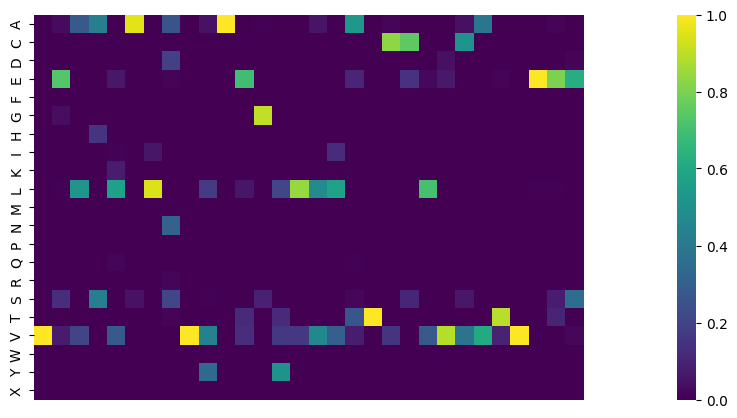

In [ ]:


print(np.unique(sequences))
print(round(np.count_nonzero(sequences == 'I') / (sequences.shape[0]*sequences.shape[1]), 4))

function_dict = {
        'phobic': list('GAM'),
        'bcaa': list('ILV'),
        'philic': list('CPSTNQ'),
        'pos': list('KRH'),
        'neg': list('DE'),
        'aro': list('FYW')
    }

pol_dict = {
        'bcaa': list('ILV'),
        'phobic': list('WCMF'),
        'mid': list('GRSTAP'),
        'philic': list('EDKNQHY')
    }

residue_to_function = {
        residue: category
        for category, residues in pol_dict.items()
        for residue in residues
    }

mapped = np.array([
    [residue_to_function[r] for r in row]
    for row in sequences
])

phobic = round(np.count_nonzero(mapped == 'phobic') / (sequences.shape[0]*sequences.shape[1]), 3)
bcaa = round(np.count_nonzero(mapped == 'bcaa') / (sequences.shape[0]*sequences.shape[1]), 3)
mid = round(np.count_nonzero(mapped == 'mid') / (sequences.shape[0]*sequences.shape[1]), 3)
philic = round(np.count_nonzero(mapped == 'philic') / (sequences.shape[0]*sequences.shape[1]), 3)

print(phobic, bcaa, mid, philic)
print(sum([phobic, bcaa, mid, philic]))

aa_to_idx = {aa:i for i, aa in enumerate(alphabet)}
counts = np.zeros((21, L), dtype=int)
for seq in sequences:
    for j, aa in enumerate(seq):
        counts[aa_to_idx[aa], j] += 1

freq = counts / (seeds*trials)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 5))
sns.heatmap(freq, cmap='viridis', yticklabels=alphabet, xticklabels=False, square=True)
plt.show()
